### **Import Libraries**

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

### **Binary Classification**

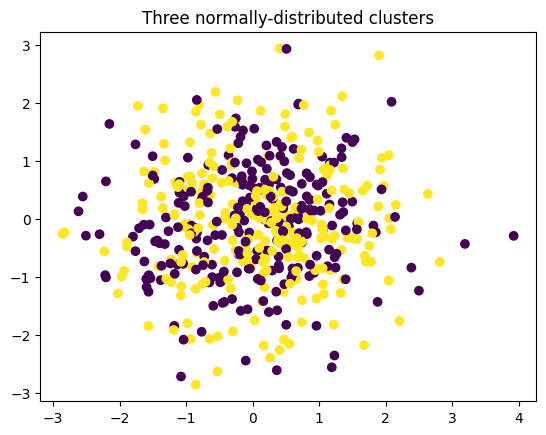

In [41]:
### Dataset generating
X, y = make_classification(n_samples=500, n_features=20, n_classes=2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Three normally-distributed clusters")
plt.show()

In [42]:
X.shape

(500, 20)

In [43]:
X[:2]

array([[-0.20367375, -0.22647889,  1.22693322, -0.82688035, -0.01414964,
        -0.5822391 , -0.60221206,  1.66125921, -0.99838544,  0.76608028,
         0.36736551, -0.10015408, -0.45709626,  0.46877426,  0.91358463,
        -0.5286394 , -0.87798259,  0.3017919 , -0.80317895, -0.67828627],
       [ 1.33665736,  1.22129495, -0.89542796,  0.32021658,  0.20260752,
         0.08188754,  0.18497058,  0.57645135,  1.70732981, -1.27835263,
         0.13395838, -1.3365685 , -1.50855597,  0.45275635, -0.09511165,
        -1.37483612,  1.5486393 , -0.7708188 , -0.33303762,  0.75115426]])

In [44]:
y.shape

(500,)

In [45]:
y[:5]

array([0, 0, 0, 1, 0])

In [46]:
x0 = np.ones((X.shape[0], 1))
print(x0[:10])

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [47]:
X = np.hstack((x0, X))
y = y.reshape(len(y), 1)

print(X.shape)
print(y.shape)

(500, 21)
(500, 1)


In [48]:
y

array([[0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
    

In [49]:
X[:2]

array([[ 1.        , -0.20367375, -0.22647889,  1.22693322, -0.82688035,
        -0.01414964, -0.5822391 , -0.60221206,  1.66125921, -0.99838544,
         0.76608028,  0.36736551, -0.10015408, -0.45709626,  0.46877426,
         0.91358463, -0.5286394 , -0.87798259,  0.3017919 , -0.80317895,
        -0.67828627],
       [ 1.        ,  1.33665736,  1.22129495, -0.89542796,  0.32021658,
         0.20260752,  0.08188754,  0.18497058,  0.57645135,  1.70732981,
        -1.27835263,  0.13395838, -1.3365685 , -1.50855597,  0.45275635,
        -0.09511165, -1.37483612,  1.5486393 , -0.7708188 , -0.33303762,
         0.75115426]])

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 21)
(100, 21)
(400, 1)
(100, 1)


In [51]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [52]:
alpha = 0.1
iterations = 5000
Loss = []

m, n = X_train.shape

theta = np.zeros((n, 1))

for iter in range(iterations):
    Z = np.dot(X_train, theta)
    h_x = sigmoid(Z)
    error = h_x - y_train
    loss = -np.sum((y_train * np.log(h_x) + ((1-y_train) * np.log(1 - h_x))))/m
    Loss.append(loss)
    theta = theta - (alpha * np.dot(X_train.T, error))/m
    if iter%1000 ==0:
      print(f"{iter} iteration: Loss -> {loss}")
print("===="*10)
print(f"Final updated theta params: \n {theta}")

0 iteration: Loss -> 0.6931471805599452
1000 iteration: Loss -> 0.2781361959033014
2000 iteration: Loss -> 0.2781038752873807
3000 iteration: Loss -> 0.2781038026468071
4000 iteration: Loss -> 0.2781038024751198
Final updated theta params: 
 [[-0.19353643]
 [ 0.34798041]
 [ 0.24214671]
 [ 0.00694847]
 [ 0.02184088]
 [-0.24821265]
 [ 0.64208685]
 [ 0.35831545]
 [-0.11751324]
 [ 0.20828786]
 [-0.05947557]
 [ 0.04433591]
 [-0.158187  ]
 [-0.01700086]
 [-0.37646494]
 [ 0.08116703]
 [ 2.48869053]
 [-0.09590565]
 [-0.17338064]
 [-0.05942477]
 [-0.11433117]]


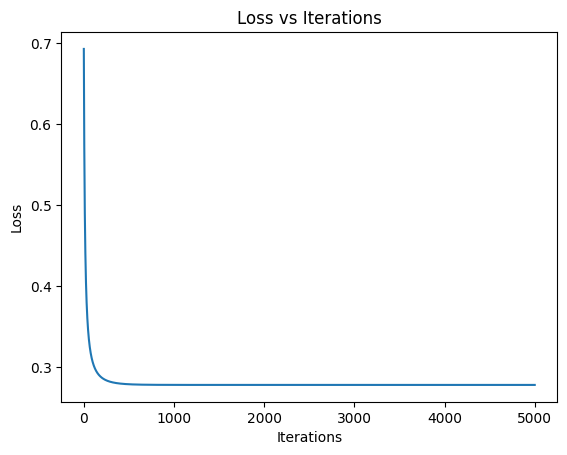

In [53]:
# Plot the loss over iterations
plt.plot(range(iterations), Loss)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [54]:
### Testing the model

def prediction(x_test, theta):
    Z = np.dot(x_test, theta)
    h_x = sigmoid(Z)
    if h_x[0][0] >= 0.5:
        pred = 1
    else:
        pred = 0
    return pred

In [55]:
pred_list = []
for indx in range(len(y_test)):
    label = y_test[indx]
    test_sample = X_test[indx].reshape(1, -1)
    pred = prediction(x_test=test_sample, theta=theta)
    pred_list.append(pred)
    print(f"My model prediction: {pred} ---> Target label {label[0]}")

My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model prediction: 1 ---> Target label 1
My model prediction: 1 ---> Target label 1
My model prediction: 1 ---> Target label 0
My model prediction: 1 ---> Target label 1
My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model prediction: 1 ---> Target label 1
My model prediction: 0 ---> Target label 0
My model prediction: 1 ---> Target label 1
My model prediction: 0 ---> Target label 0
My model prediction: 1 ---> Target label 1
My model prediction: 0 ---> Target label 0
My model prediction: 1 ---> Target label 1
My model prediction: 1 ---> Target label 1
My model prediction: 0 ---> Target label 1
My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model prediction: 0 ---> Target label 0
My model pr

### **Model Evaluation**

In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Compute metrics
pred = np.array(pred)
precision = precision_score(y_test, pred, average="macro")
recall = recall_score(y_test, pred, average="macro")
f1 = f1_score(y_test, pred, average="macro")
cm = confusion_matrix(y_test, pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, pred))

TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(0)` instead.

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix Heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'cm' is not defined

<Figure size 600x500 with 0 Axes>

### **Multi-Class Classification**

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Generate a multiclass dataset (3 classes)
X, y = make_classification(
    n_samples=500,
    n_features=2,      # easy to visualize
    n_informative=2,   # number of informative features
    n_redundant=0,     # no redundant features
    n_classes=3,       # <-- multiclass here
    n_clusters_per_class=1,
    random_state=42
)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", edgecolor="k", s=60)
plt.title("Multiclass dataset generated with make_classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
# Adding intercept term (bias) to the dataset
X = np.hstack([np.ones((X.shape[0], 1)), X])  # Adding a column of 1s
print(X.shape)
print(y.shape)

In [ ]:
y[:10]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loss function (Binary Cross-Entropy)
def loss_function(h, y):
    return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

# One-vs-all logistic regression model training
def train_one_vs_all(X, y, num_labels, alpha, iterations):
    m, n = X.shape
    theta = np.zeros((num_labels, n))  # Initialize parameters for each class
    all_losses = []

    for c in range(num_labels):
        theta_c = np.zeros((n, 1))  # Initialize weights for class `c`
        y_c = np.where(y == c, 1, 0).reshape(-1, 1)  # Convert y to binary for class `c`
        losses = []

        for i in range(iterations):
            z = np.dot(X, theta_c)
            h = sigmoid(z)
            error = h - y_c
            loss = loss_function(h, y_c)
            losses.append(loss)
            if i%100 == 0:
                print(f"{i} iteration, Loss: {loss}")

            # Gradient descent
            theta_c = theta_c - alpha * (np.dot(X.T, error)) / m

        theta[c, :] = theta_c.T
        all_losses.append(losses)

    return theta, all_losses

# Making predictions
def predict_one_vs_all(X, theta):
    z = np.dot(X, theta.T)
    h = sigmoid(z)
    return np.argmax(h, axis=1)


In [ ]:
# Training logistic regression models for each class
num_labels = 3  # We have 3 classes (0, 1, 2)
alpha = 0.1
iterations = 1000
theta, all_losses = train_one_vs_all(X_train, y_train, num_labels, alpha, iterations)

In [ ]:
# Testing the model on new input

pred = predict_one_vs_all(X_test, theta)
correct_output = 0
for i in range(len(y_test)):
  if pred[i] == y_test[i]:
    correct_output +=1
  print(f"Prediction: {pred[i]} ---> Terget: {y_test[i]}")

print("==="*10)
print(f"Correct predictions {correct_output} out of {len(y_test)}")


In [ ]:
# Plotting the loss for each class
for i in range(num_labels):
    plt.plot(range(iterations), all_losses[i], label=f'Class {i}')
plt.title("Loss vs Iterations for each class")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
theta

### Logistic Regression with Regularization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset (same as before but regularization added)
X = np.array([[1, 2], [2, 3], [3, 3], [5, 5], [2, 1], [3, 5], [2, 5], [1, 4], [5, 2], [4, 4]])
y = np.array([0, 1, 2, 1, 0, 2, 2, 0, 1, 1])  # 3 classes: 0, 1, 2

# Add intercept term
X = np.hstack([np.ones((X.shape[0], 1)), X])  # Add bias term (ones)

In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cost function with regularization (Binary Cross-Entropy)
def loss_function(h, y, theta, reg_lambda, m):
    regularization_term = (reg_lambda / (2 * m)) * np.sum(np.square(theta[1:]))
    return (-1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h)) + regularization_term

# One-vs-all logistic regression model training with regularization
def train_one_vs_all(X, y, num_labels, alpha, iterations, reg_lambda):
    m, n = X.shape
    theta = np.zeros((num_labels, n))  # Initialize parameters for each class
    all_losses = []

    for c in range(num_labels):
        theta_c = np.zeros((n, 1))  # Initialize weights for class `c`
        y_c = np.where(y == c, 1, 0).reshape(-1, 1)  # Convert y to binary for class `c`
        losses = []

        for i in range(iterations):
            z = np.dot(X, theta_c)
            h = sigmoid(z)
            error = h - y_c
            loss = loss_function(h, y_c, theta_c, reg_lambda, m)
            losses.append(loss)
            if i%100 == 0:
                print(f"{i} iteration, Loss: {loss}")

            # Gradient descent with regularization
            grad = (1 / m) * np.dot(X.T, error)
            grad[1:] = grad[1:] + (reg_lambda / m) * theta_c[1:]  # Regularize theta_j (not theta_0)
            theta_c -= alpha * grad

        theta[c, :] = theta_c.T
        all_losses.append(losses)

    return theta, all_losses

# Making predictions
def predict_one_vs_all(X, theta):
    z = np.dot(X, theta.T)
    h = sigmoid(z)
    return np.argmax(h, axis=1)


In [ ]:
# Training logistic regression models for each class with regularization
num_labels = 3  # We have 3 classes (0, 1, 2)
alpha = 0.1
iterations = 1000
reg_lambda = 1  # Regularization parameter
theta, all_losses = train_one_vs_all(X, y, num_labels, alpha, iterations, reg_lambda)

In [ ]:
# Testing the model on a new input
x_test = np.array([[1, 3, 3]])  # Add intercept term
pred = predict_one_vs_all(x_test, theta)
print(f"Predicted class for test sample: {pred[0]}")

In [ ]:
# Plotting the loss for each class
for i in range(num_labels):
    plt.plot(range(iterations), all_losses[i], label=f'Class {i}')
plt.title("Loss vs Iterations for each class (with regularization)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()